In [ ]:
!apt-get install -y fonts-nanum > /dev/null

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from xgboost import XGBRegressor

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

train_df = pd.read_csv(DATA_DIR + 'train_fe.csv')

print('로드 완료')
print('train shape:', train_df.shape)

Mounted at /content/drive
로드 완료
train shape: (204000, 35)


In [ ]:
result_path = DATA_DIR + 'experiment_results.csv'

existing_results = pd.read_csv(result_path)
print('=== 기존 실험 결과 ===')
print(existing_results.to_string(index=False))

# 실험 4 SMAPE 불러오기
score_exp4 = existing_results[existing_results['실험번호'] == 4]['SMAPE'].values[0]
best_params = {'max_depth': 8, 'min_child_weight': 1,
               'subsample': 0.9, 'colsample_bytree': 0.9}
print(f'\n실험 4 SMAPE: {score_exp4}')

=== 기존 실험 결과 ===
 실험번호                 실험명     SMAPE       개선폭                                                                                         비고
    0 대회_Baseline_XGBoost 24.014000  0.000000                                                     대회 제공 Baseline, Feature Engineering 없음
    1          FE_XGBoost  8.424200 15.589800                                                                  Feature Engineering 추가 효과
    2         LightGBM_전체  9.388100 -0.963900                                                                            XGBoost보다 성능 낮음
    3         유형별_XGBoost  7.257900  2.130200                                                                            유형별 모델 분리 효과 확인
    4      유형별_XGBoost_튜닝  6.889891  0.368009 최적파라미터: {'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9, 'colsample_bytree': 0.9}

실험 4 SMAPE: 6.889890997755242


In [ ]:
TRAIN_FEATURES = [
    '건물번호', 'building_type_enc',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)',
    'has_solar', 'has_ess', 'is_IDC',
    'month', 'day', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'THI', 'CDH',
    'building_hour_mean', 'building_weekday_mean', 'building_mean',
    '일조(hr)', '일사(MJ/m2)',
]
TARGET = '전력소비량(kWh)'

def smape(true, pred):
    true, pred = np.array(true), np.array(pred)
    return np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred))) * 100

val_mask_all   = train_df['일시'] >= '20240818 00'
train_mask_all = train_df['일시'] < '20240818 00'

print(f'학습 데이터: {train_mask_all.sum():,}행')
print(f'검증 데이터: {val_mask_all.sum():,}행')

학습 데이터: 187,200행
검증 데이터: 16,800행


In [ ]:
# 건물 100개 각각 따로 모델 학습
# 같은 유형 안에서도 건물마다 다른 패턴을 반영

building_nums = train_df['건물번호'].unique()
models_exp5   = {}
preds_exp5    = np.zeros(len(train_df))

for bnum in sorted(building_nums):
    train_mask = (train_df['일시'] < '20240818 00') & (train_df['건물번호'] == bnum)
    val_mask   = (train_df['일시'] >= '20240818 00') & (train_df['건물번호'] == bnum)

    tx = train_df[TRAIN_FEATURES][train_mask]
    ty = train_df[TARGET][train_mask]
    vx = train_df[TRAIN_FEATURES][val_mask]
    vy = train_df[TARGET][val_mask]

    if len(tx) == 0 or len(vx) == 0:
        print(f'  건물 {bnum} → 데이터 없음, 건너뜀')
        continue

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae',
        **best_params
    )
    model.fit(
        tx, ty,
        eval_set=[(vx, vy)],
        verbose=False
    )

    models_exp5[bnum] = model
    preds_exp5[val_mask.values] = model.predict(vx)

print(f'전체 {len(models_exp5)}개 건물 학습 완료')

score_exp5 = smape(
    train_df[TARGET][val_mask_all],
    preds_exp5[val_mask_all.values]
)

print(f'\n실험 5 Validation SMAPE: {score_exp5:.4f}')
print(f'실험 4 대비 개선: {score_exp4 - score_exp5:.4f}')

전체 100개 건물 학습 완료

실험 5 Validation SMAPE: 7.0299
실험 4 대비 개선: -0.1401


In [ ]:
# 어떤 건물이 예측이 잘 되고 안 되는지 확인

building_scores = []

for bnum in sorted(building_nums):
    val_mask = (train_df['일시'] >= '20240818 00') & (train_df['건물번호'] == bnum)
    true = train_df[TARGET][val_mask]
    pred = preds_exp5[val_mask.values]

    if len(true) == 0:
        continue

    score = smape(true, pred)
    btype = train_df[train_df['건물번호'] == bnum]['건물유형'].values[0]
    building_scores.append({
        '건물번호': bnum,
        '건물유형': btype,
        'SMAPE': score
    })

building_score_df = pd.DataFrame(building_scores).sort_values('SMAPE', ascending=False)

print('=== SMAPE 상위 10개 (예측이 어려운 건물) ===')
print(building_score_df.head(10).to_string(index=False))
print()
print('=== SMAPE 하위 10개 (예측이 잘 되는 건물) ===')
print(building_score_df.tail(10).to_string(index=False))

# 건물유형별 평균 SMAPE
print('\n=== 건물유형별 평균 SMAPE ===')
print(building_score_df.groupby('건물유형')['SMAPE']
      .mean().sort_values(ascending=False).round(4))

=== SMAPE 상위 10개 (예측이 어려운 건물) ===
 건물번호 건물유형     SMAPE
    7 건물기타 45.999126
   94  연구소 26.374323
   10   호텔 25.500472
   61 건물기타 18.108808
   54  백화점 17.231654
   87   학교 16.213643
   49  연구소 15.378255
   19  백화점 15.075319
   33   공공 13.907869
  100   호텔 13.692081

=== SMAPE 하위 10개 (예측이 잘 되는 건물) ===
 건물번호     건물유형    SMAPE
   67 IDC(전화국) 1.889317
   55       학교 1.680606
   76       상용 1.425593
   51       상용 1.254430
   56       상용 0.899147
   57 IDC(전화국) 0.820413
   41       상용 0.512352
   30 IDC(전화국) 0.463407
   36 IDC(전화국) 0.452670
   35 IDC(전화국) 0.385689

=== 건물유형별 평균 SMAPE ===
건물유형
건물기타        10.7444
연구소         10.2148
호텔           9.0618
백화점          8.5103
공공           7.8038
학교           6.6444
아파트          5.8102
병원           4.5027
상용           3.8635
IDC(전화국)     1.8343
Name: SMAPE, dtype: float64


실험 5 결과 저장 완료

실험 결과 비교
실험명                                 SMAPE      개선폭
----------------------------------------------------
대회_Baseline_XGBoost               24.0140  +0.0000
FE_XGBoost                         8.4242 +15.5898
LightGBM_전체                        9.3881  -0.9639
유형별_XGBoost                        7.2579  +2.1302
유형별_XGBoost_튜닝                     6.8899  +0.3680
건물별_XGBoost_튜닝                     7.0299  -0.1401


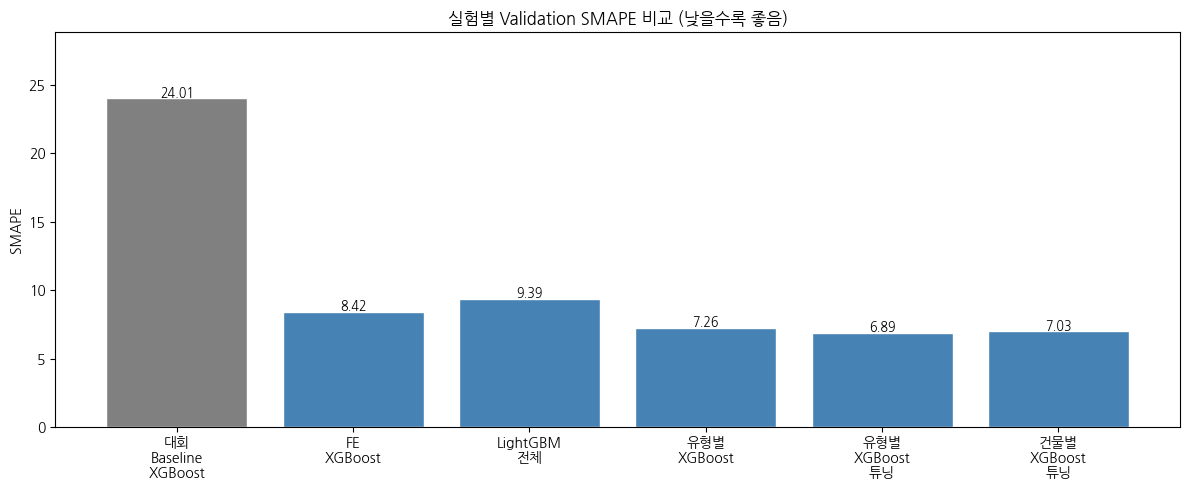

In [ ]:
new_result = pd.DataFrame([{
    '실험번호': 5,
    '실험명': '건물별_XGBoost_튜닝',
    'SMAPE': score_exp5,
    '개선폭': score_exp4 - score_exp5,
    '비고': '100개 건물 각각 개별 모델 학습'
}])

combined = pd.concat([existing_results, new_result], ignore_index=True)
combined = combined.drop_duplicates(subset='실험번호', keep='last')
combined = combined.sort_values('실험번호').reset_index(drop=True)
combined.to_csv(result_path, index=False)

print('실험 5 결과 저장 완료')
print()

# 비교표
print('=' * 52)
print('실험 결과 비교')
print('=' * 52)
print(f'{"실험명":<32} {"SMAPE":>8} {"개선폭":>8}')
print('-' * 52)
for _, row in combined.iterrows():
    print(f'{row["실험명"]:<32} {row["SMAPE"]:>8.4f} {row["개선폭"]:>+8.4f}')
print('=' * 52)

# 시각화
plt.figure(figsize=(12, 5))
labels = [name.replace('_', '\n') for name in combined['실험명']]
scores = combined['SMAPE'].tolist()
colors = ['gray'] + ['steelblue'] * (len(combined) - 1)

bars = plt.bar(labels, scores, color=colors, edgecolor='white')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{score:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.title('실험별 Validation SMAPE 비교 (낮을수록 좋음)')
plt.ylabel('SMAPE')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()